<a href="https://colab.research.google.com/github/fboldt/aulasml/blob/master/aula11b_isolation_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

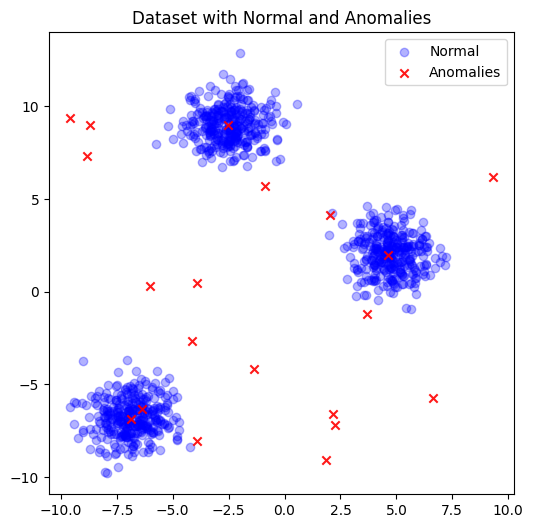

In [17]:
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

n_samples = 980
n_features = 2
n_centers = 3
random_state = 42

X_normal, y_normal = make_blobs(n_samples=n_samples, n_features=n_features, centers=n_centers, random_state=random_state)
y_normal[:] = 1

n_anomalies = 20
rng = np.random.RandomState(random_state)
X_anomalies = rng.uniform(low=-10, high=10, size=(n_anomalies, n_features))

X = np.concatenate([X_normal, X_anomalies])
y = np.concatenate([y_normal, -np.ones(n_anomalies)])

plt.figure(figsize=(6, 6))
plt.scatter(X_normal[:, 0], X_normal[:, 1], color='blue', label='Normal', alpha=0.3, marker='o')
plt.scatter(X_anomalies[:, 0], X_anomalies[:, 1], color='red', label='Anomalies', alpha=0.9, marker='x')
plt.legend()
plt.title('Dataset with Normal and Anomalies')
plt.show()

In [18]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report

model = IsolationForest(contamination=0.1)
model.fit(X)
y_pred = model.predict(X)

print(classification_report(y, y_pred))

              precision    recall  f1-score   support

        -1.0       0.16      0.80      0.27        20
         1.0       1.00      0.91      0.95       980

    accuracy                           0.91      1000
   macro avg       0.58      0.86      0.61      1000
weighted avg       0.98      0.91      0.94      1000



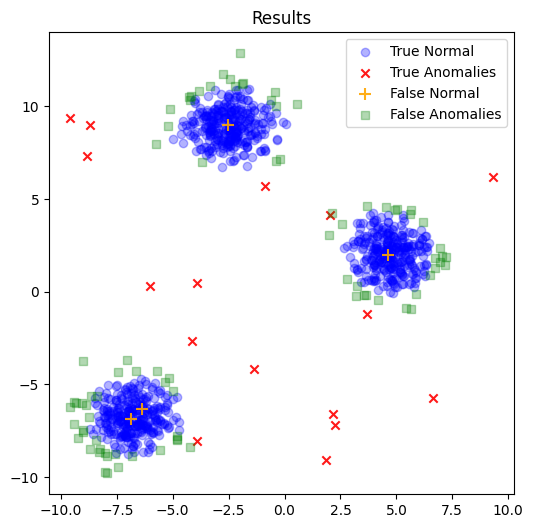

In [19]:
def plot_results(X, y, labels):
  true_normal = X[np.logical_and(y == 1, labels == 1)]
  false_normal = X[np.logical_and(y == -1, labels == 1)]
  true_anomalies = X[np.logical_and(y == -1, labels == -1)]
  false_anomalies = X[np.logical_and(y == 1, labels == -1)]

  plt.figure(figsize=(6, 6))
  plt.scatter(true_normal[:, 0], true_normal[:, 1], color='blue', label='True Normal', alpha=0.3, marker='o')
  plt.scatter(true_anomalies[:, 0], true_anomalies[:, 1], color='red', label='True Anomalies', alpha=0.9, marker='x')
  plt.scatter(false_normal[:, 0], false_normal[:, 1], color='orange', label='False Normal', alpha=0.9, marker='+', s=80)
  plt.scatter(false_anomalies[:, 0], false_anomalies[:, 1], color='green', label='False Anomalies', alpha=0.3, marker='s')
  plt.legend()
  plt.title('Results')
  plt.show()

plot_results(X, y, y_pred)

In [20]:
!pip install optuna -qq

In [ ]:
import optuna
from sklearn.ensemble import IsolationForest
from sklearn.metrics import f1_score, classification_report

# Define the objective function for Optuna
def objective(trial):
    # Suggest hyperparameters
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_samples_ratio = trial.suggest_float('max_samples_ratio', 0.1, 1.0)
    contamination = trial.suggest_float('contamination', 0.01, 0.2)

    # Create the IsolationForest model
    model = IsolationForest(
        n_estimators=n_estimators,
        max_samples=max_samples_ratio, # max_samples can be a float (proportion)
        contamination=contamination,
        random_state=42, # Ensure reproducibility
        n_jobs=-1 # Use all available cores
    )

    # Train and evaluate the model
    model.fit(X)
    y_pred = model.predict(X)

    # Calculate the F1-score for the anomaly class (-1)
    f1 = f1_score(y, y_pred, pos_label=-1)

    return f1

# Create an Optuna study and optimize
study = optuna.create_study(direction='maximize') # We want to maximize the F1-score
study.optimize(objective, n_trials=50, show_progress_bar=True) # Run 50 trials

# Print the best hyperparameters and best score
print("\nBest trial:")
print(f"  Value (F1-score for anomalies): {study.best_value:.4f}")
print("  Params: ")
for key, value in study.best_params.items():
    print(f"    {key}: {value}")

# Optionally, train the best model and print classification report
best_params = study.best_params
best_model = IsolationForest(
    n_estimators=best_params['n_estimators'],
    max_samples=best_params['max_samples_ratio'],
    contamination=best_params['contamination'],
    random_state=42,
    n_jobs=-1
)
best_model.fit(X)


Classification Report for Best Model:
              precision    recall  f1-score   support

        -1.0       0.72      0.65      0.68        20
         1.0       0.99      0.99      0.99       980

    accuracy                           0.99      1000
   macro avg       0.86      0.82      0.84      1000
weighted avg       0.99      0.99      0.99      1000



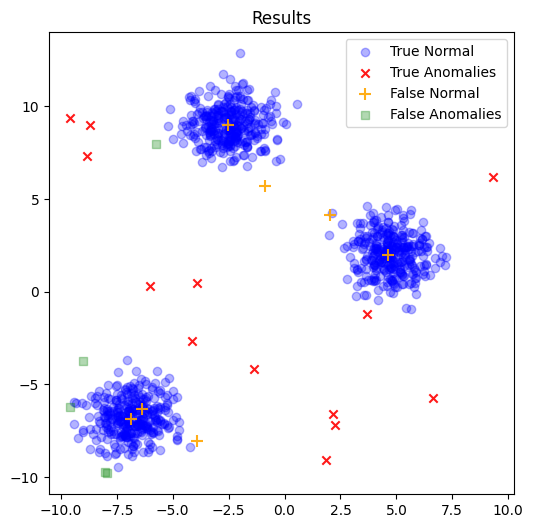

In [22]:
y_pred_best = best_model.predict(X)
print("\nClassification Report for Best Model:")
print(classification_report(y, y_pred_best))
plot_results(X, y, y_pred_best)

              precision    recall  f1-score   support

        -1.0       0.16      0.80      0.27        20
         1.0       1.00      0.91      0.95       980

    accuracy                           0.91      1000
   macro avg       0.58      0.86      0.61      1000
weighted avg       0.98      0.91      0.94      1000



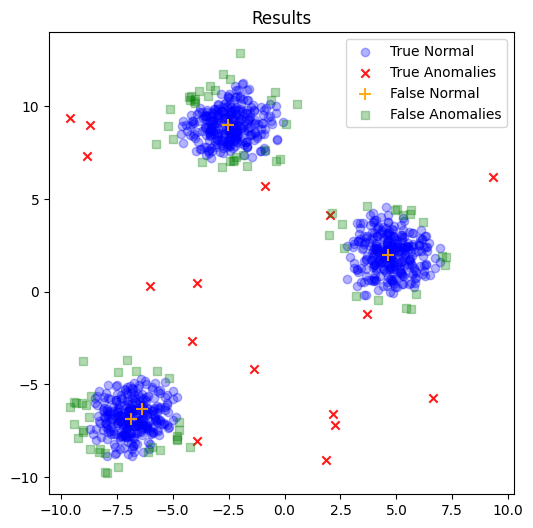

In [23]:
from sklearn.neighbors import LocalOutlierFactor

model = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
y_pred = model.fit_predict(X)

print(classification_report(y, y_pred))
plot_results(X, y, y_pred)

In [ ]:
import optuna
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import f1_score, classification_report

# Define the objective function for Optuna
def objective_lof(trial):
    # Suggest hyperparameters for LocalOutlierFactor
    n_neighbors = trial.suggest_int('n_neighbors', 5, 50)
    contamination = trial.suggest_float('contamination', 0.01, 0.2)

    # Create the LocalOutlierFactor model
    model_lof = LocalOutlierFactor(
        n_neighbors=n_neighbors,
        contamination=contamination,
        novelty=False, # For outlier detection on the training set
        n_jobs=-1
    )

    # Train and predict anomaly labels
    y_pred_lof = model_lof.fit_predict(X)

    # Calculate the F1-score for the anomaly class (-1)
    f1 = f1_score(y, y_pred_lof, pos_label=-1)

    return f1

# Create an Optuna study and optimize
study_lof = optuna.create_study(direction='maximize', study_name='LOF_Optimization') # Maximize F1-score
study_lof.optimize(objective_lof, n_trials=50, show_progress_bar=True) # Run 50 trials

# Print the best hyperparameters and best score
print("\nBest trial for LocalOutlierFactor:")
print(f"  Value (F1-score for anomalies): {study_lof.best_value:.4f}")
print("  Params: ")
for key, value in study_lof.best_params.items():
    print(f"    {key}: {value}")

# Train the best LOF model and print classification report
best_params_lof = study_lof.best_params
best_model_lof = LocalOutlierFactor(
    n_neighbors=best_params_lof['n_neighbors'],
    contamination=best_params_lof['contamination'],
    novelty=False,
    n_jobs=-1
)



Classification Report for Best LocalOutlierFactor Model:
              precision    recall  f1-score   support

        -1.0       0.83      0.75      0.79        20
         1.0       0.99      1.00      1.00       980

    accuracy                           0.99      1000
   macro avg       0.91      0.87      0.89      1000
weighted avg       0.99      0.99      0.99      1000



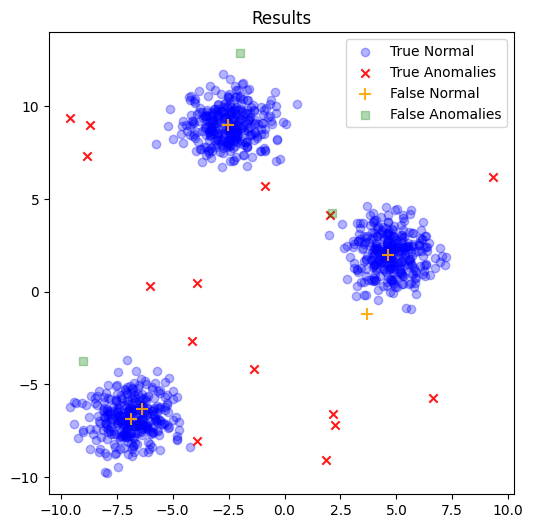

In [25]:
best_y_pred_lof = best_model_lof.fit_predict(X)
print("\nClassification Report for Best LocalOutlierFactor Model:")
print(classification_report(y, best_y_pred_lof))

# Plot the results of the best LOF model
plot_results(X, y, best_y_pred_lof)

              precision    recall  f1-score   support

        -1.0       0.14      0.70      0.24        20
         1.0       0.99      0.91      0.95       980

    accuracy                           0.91      1000
   macro avg       0.57      0.81      0.59      1000
weighted avg       0.98      0.91      0.94      1000



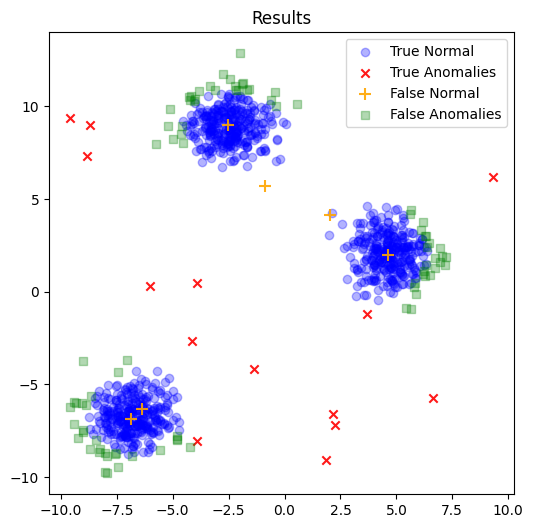

In [26]:
from sklearn.svm import OneClassSVM

model = OneClassSVM(nu=0.1, kernel='rbf', gamma='scale')
y_pred = model.fit_predict(X)

print(classification_report(y, y_pred))
plot_results(X, y, y_pred)

In [ ]:
import optuna
from sklearn.svm import OneClassSVM
from sklearn.metrics import f1_score, classification_report

# Define the objective function for Optuna
def objective_ocsvm(trial):
    # Suggest hyperparameters for OneClassSVM
    nu = trial.suggest_float('nu', 0.01, 0.2) # An upper bound of 0.2 for nu, considering the dataset's anomaly proportion
    kernel = trial.suggest_categorical('kernel', ['rbf', 'poly', 'sigmoid'])

    if kernel == 'rbf':
        gamma = trial.suggest_float('gamma', 1e-4, 1e-1, log=True)
    elif kernel == 'poly':
        gamma = trial.suggest_float('gamma', 1e-4, 1e-1, log=True)
        degree = trial.suggest_int('degree', 2, 5)
        coef0 = trial.suggest_float('coef0', 0.0, 1.0)
    elif kernel == 'sigmoid':
        gamma = trial.suggest_float('gamma', 1e-4, 1e-1, log=True)
        coef0 = trial.suggest_float('coef0', 0.0, 1.0)

    # Create the OneClassSVM model
    if kernel == 'rbf':
        model_ocsvm = OneClassSVM(nu=nu, kernel=kernel, gamma=gamma)
    elif kernel == 'poly':
        model_ocsvm = OneClassSVM(nu=nu, kernel=kernel, gamma=gamma, degree=degree, coef0=coef0)
    elif kernel == 'sigmoid':
        model_ocsvm = OneClassSVM(nu=nu, kernel=kernel, gamma=gamma, coef0=coef0)

    # Train and predict anomaly labels
    model_ocsvm.fit(X)
    y_pred_ocsvm = model_ocsvm.predict(X)

    # Calculate the F1-score for the anomaly class (-1)
    f1 = f1_score(y, y_pred_ocsvm, pos_label=-1)

    return f1

# Create an Optuna study and optimize
study_ocsvm = optuna.create_study(direction='maximize', study_name='OneClassSVM_Optimization') # Maximize F1-score
study_ocsvm.optimize(objective_ocsvm, n_trials=50, show_progress_bar=True) # Run 50 trials

# Print the best hyperparameters and best score
print("\nBest trial for OneClassSVM:")
print(f"  Value (F1-score for anomalies): {study_ocsvm.best_value:.4f}")
print("  Params: ")
for key, value in study_ocsvm.best_params.items():
    print(f"    {key}: {value}")

# Train the best OneClassSVM model and print classification report
best_params_ocsvm = study_ocsvm.best_params

if best_params_ocsvm['kernel'] == 'rbf':
    best_model_ocsvm = OneClassSVM(
        nu=best_params_ocsvm['nu'],
        kernel=best_params_ocsvm['kernel'],
        gamma=best_params_ocsvm['gamma']
    )
elif best_params_ocsvm['kernel'] == 'poly':
    best_model_ocsvm = OneClassSVM(
        nu=best_params_ocsvm['nu'],
        kernel=best_params_ocsvm['kernel'],
        gamma=best_params_ocsvm['gamma'],
        degree=best_params_ocsvm['degree'],
        coef0=best_params_ocsvm['coef0']
    )
elif best_params_ocsvm['kernel'] == 'sigmoid':
    best_model_ocsvm = OneClassSVM(
        nu=best_params_ocsvm['nu'],
        kernel=best_params_ocsvm['kernel'],
        gamma=best_params_ocsvm['gamma'],
        coef0=best_params_ocsvm['coef0']
    )

best_model_ocsvm.fit(X)



Classification Report for Best OneClassSVM Model:
              precision    recall  f1-score   support

        -1.0       0.53      0.80      0.64        20
         1.0       1.00      0.99      0.99       980

    accuracy                           0.98      1000
   macro avg       0.76      0.89      0.82      1000
weighted avg       0.99      0.98      0.98      1000



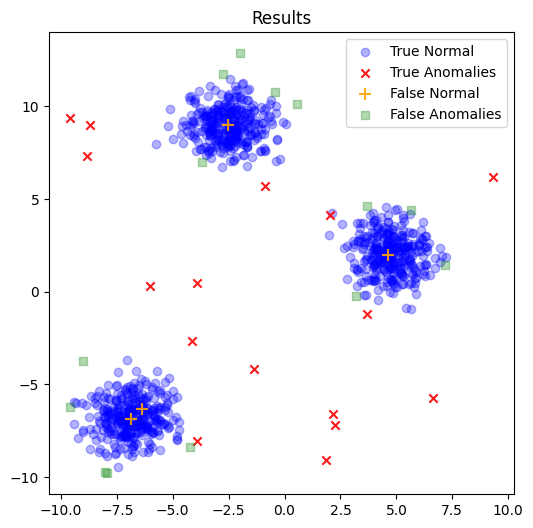

In [28]:
best_y_pred_ocsvm = best_model_ocsvm.predict(X)
print("\nClassification Report for Best OneClassSVM Model:")
print(classification_report(y, best_y_pred_ocsvm))

# Plot the results of the best OneClassSVM model
plot_results(X, y, best_y_pred_ocsvm)